In [51]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Rescaling
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers


In [52]:
gpus = tf.config.experimental.list_physical_devices('GPU')

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [53]:
data = tf.keras.utils.image_dataset_from_directory(
    'data',                
    image_size=(224, 224),
    batch_size=32          
)
data

Found 2000 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [54]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
print(f"Cabbirka hal Batch: {batch[0].shape}")

Cabbirka hal Batch: (32, 224, 224, 3)


In [55]:
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = int(len(data) * 0.1)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

AUTOTUNE = tf.data.AUTOTUNE

# Train-ka: Waa la keydiyaa (cache), waa la isku qasaa (shuffle), waana lasii diyaariyaa (prefetch)
train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Validation-ka: Kaliya waa la keydiyaa oo lasii diyaariyaa (Shuffle uma baahna)
val = val.cache().prefetch(buffer_size=AUTOTUNE)

# Test-ka (haddii aad isticmaaleyso): Isagana waa la keydiyaa
test = test.cache().prefetch(buffer_size=AUTOTUNE)

In [56]:
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Xir

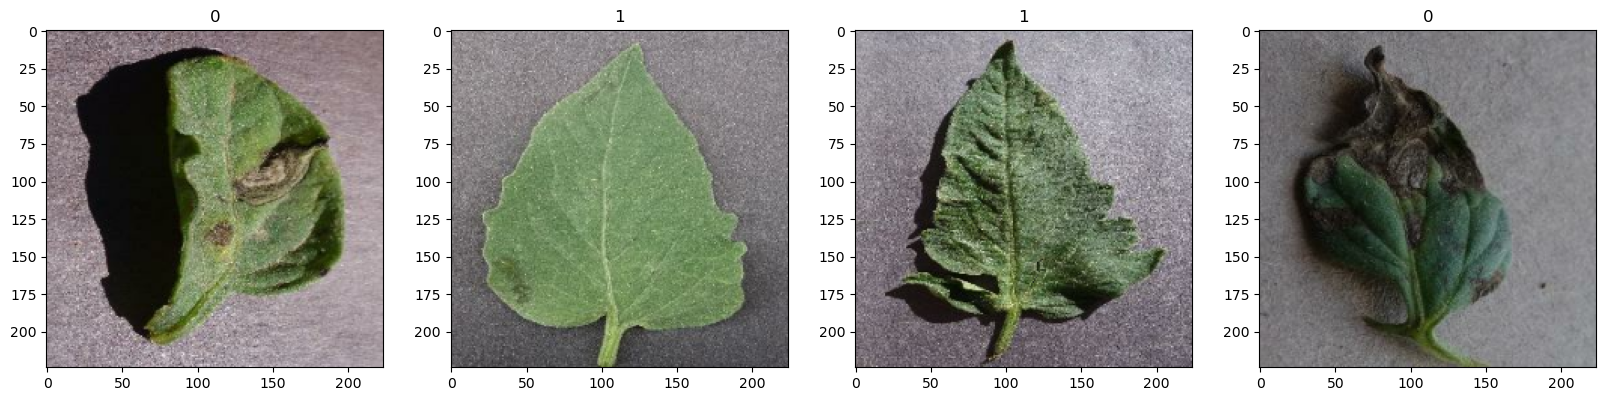

In [57]:
fig, ax = plt.subplots(ncols=4,figsize=(20,20))

for idx, img in enumerate(batch[0][0:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

plt.show()

In [72]:

# Tani waxay abuuraysaa sawiro cusub oo la rog-rogay xilliga tababarka
data_augmentation = Sequential([
  layers.RandomFlip("horizontal_and_vertical"), # Caleenta kor iyo hoos u rog
  layers.RandomRotation(0.2),                  # Wareeji caleenta (20%)
  layers.RandomZoom(0.2),                      # Soo dhawee ama fogee
  layers.RandomContrast(0.1),                  # Iftiinka wax yar ka bedel
])

model = Sequential()

model.add(data_augmentation)

model.add(Rescaling(1./255, input_shape=(224, 224, 3)))

model.add(base_model)

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


print("--- Tababarka ayaa bilaabanaya... ---")
history = model.fit(train, epochs=5, validation_data=val)

--- Tababarka ayaa bilaabanaya... ---
Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8757 - loss: 2.7463 - val_accuracy: 0.9818 - val_loss: 0.1490
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9702 - loss: 0.3435 - val_accuracy: 0.9922 - val_loss: 0.0231
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9723 - loss: 0.1807 - val_accuracy: 0.9427 - val_loss: 0.2264
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9716 - loss: 0.1147 - val_accuracy: 0.9870 - val_loss: 0.0320
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9730 - loss: 0.0722 - val_accuracy: 0.9870 - val_loss: 0.0375


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Nambarka uu AI-gu soo saaray: 3.0791477456659777e-07


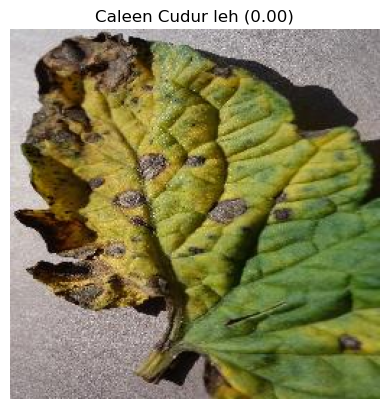

In [76]:

# 1. Soo rar sawirka
img = cv2.imread('disease_tomato1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

resize = tf.image.resize(img_rgb, (224, 224))

yhat = model.predict(np.expand_dims(resize, 0))

score = yhat[0][0]
print(f"Nambarka uu AI-gu soo saaray: {score}")

if score > 0.5:
    result_text = f"Caleen Caafimaad qabta ({score:.2f})"
else:
    result_text = f"Caleen Cudur leh ({score:.2f})"

plt.imshow(img_rgb)
plt.title(result_text)
plt.axis('off')
plt.show()

In [71]:
model.save('models/tomato_leaf_model.h5')